In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url)
data.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

In [6]:
data.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


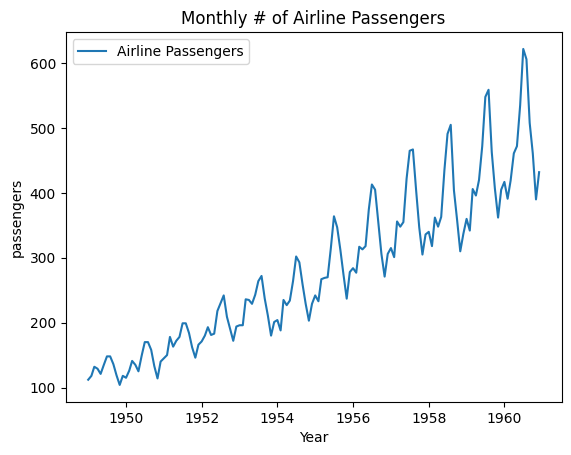

In [7]:
plt.plot(data['Passengers'], label='Airline Passengers')
plt.title('Monthly # of Airline Passengers')
plt.xlabel('Year')
plt.ylabel('passengers')
plt.legend()
plt.show()

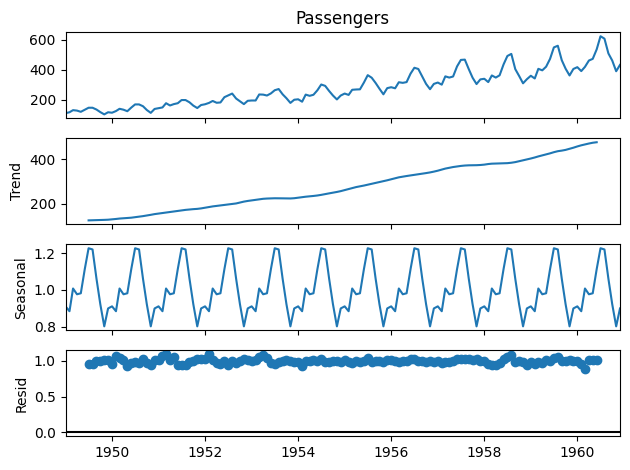

In [8]:
result = seasonal_decompose(data['Passengers'], model='multiplicative', period=12)
result.plot()
plt.show()

In [9]:
trend = result.trend
seasonal = result.seasonal
residual = result.resid

print("Trend:\n", trend.dropna().head())
print("\nSeasonal:\n", seasonal.head(15))
print("\nResidual:\n", residual.dropna().head())

Trend:
 Month
1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
1949-11-01    129.000000
Name: trend, dtype: float64

Seasonal:
 Month
1949-01-01    0.910230
1949-02-01    0.883625
1949-03-01    1.007366
1949-04-01    0.975906
1949-05-01    0.981378
1949-06-01    1.112776
1949-07-01    1.226556
1949-08-01    1.219911
1949-09-01    1.060492
1949-10-01    0.921757
1949-11-01    0.801178
1949-12-01    0.898824
1950-01-01    0.910230
1950-02-01    0.883625
1950-03-01    1.007366
Name: seasonal, dtype: float64

Residual:
 Month
1949-07-01    0.951664
1949-08-01    0.953401
1949-09-01    1.002220
1949-10-01    1.004028
1949-11-01    1.006270
Name: resid, dtype: float64


### Correlation Insights

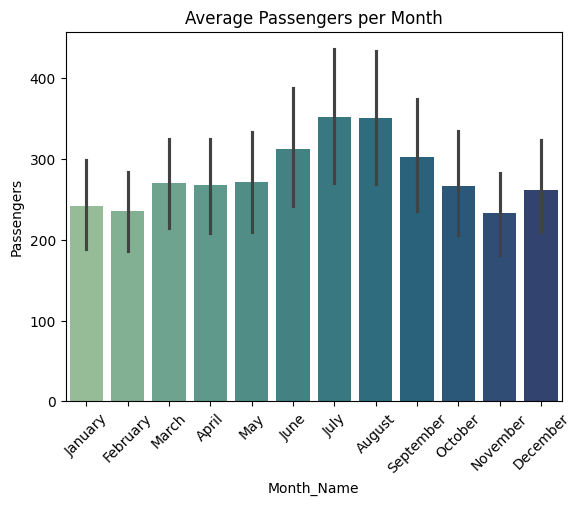

In [15]:
data['Month_Name'] = data.index.month_name()

sns.barplot(x='Month_Name', y='Passengers', data=data, hue='Month_Name',
           estimator='mean', palette='crest')
plt.title('Average Passengers per Month')
plt.xticks(rotation=45)
plt.show()

This shows which months (like July–August) typically have peak traffic.

The trend shows consistent growth.

The seasonality repeats every year (peak mid-year).

The residuals are small → the data is well structured.

This dataset is perfect for SARIMA, Holt-Winters, or Prophet forecasting.